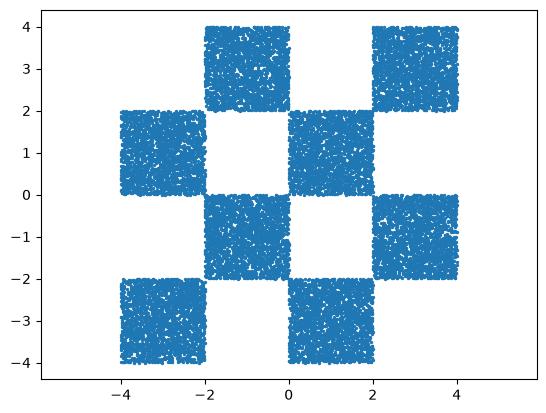

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def checkerboard(n, seed=11):
    rng = np.random.default_rng(seed)

    centres = np.array([
        [-3,  1], [-3, -3],
        [-1,  3], [-1, -1],
        [ 1,  1], [ 1, -3],
        [ 3,  3], [ 3, -1],
    ])

    tiles = rng.integers(0, 8, size=n)
    offsets = rng.uniform(-1, 1, size=(n, 2))

    return centres[tiles] + offsets


data = checkerboard(20000)

plt.scatter(data[:, 0], data[:, 1], s=2)
plt.axis("equal")
plt.show()

Step 0, Loss: 12.3332
Step 1000, Loss: 6.9995
Step 2000, Loss: 6.9170
Step 3000, Loss: 6.8537
Step 4000, Loss: 6.5532
Step 5000, Loss: 6.9942
Step 6000, Loss: 6.7595
Step 7000, Loss: 6.7732
Step 8000, Loss: 6.7090
Step 9000, Loss: 6.5973


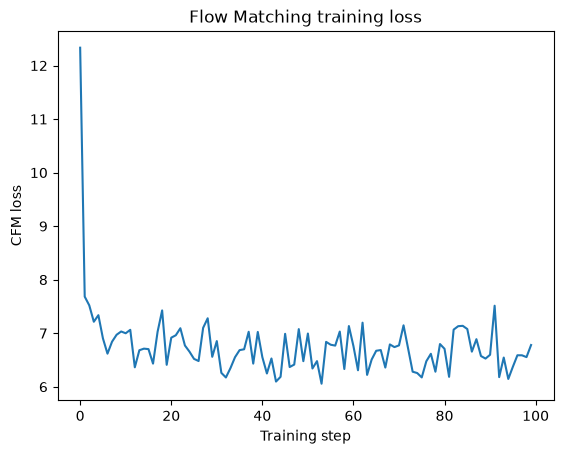

In [13]:
import torch
from torch import nn

torch.manual_seed(11)
training_data = torch.tensor(data, dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(3, 128), # 3 inputs: time, x_t[0], x_t[1]
    nn.SiLU(),
    nn.Linear(128, 128),
    nn.SiLU(),
    nn.Linear(128, 128),
    nn.SiLU(),
    nn.Linear(128, 2), # 2 outputs: predicted_velocity[0], predicted_velocity[1]
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

sigma_min = 0.1
batch_size = 512
training_steps = 10000 
loss_history = []


#Training loop
for step in range(training_steps):
    indices = torch.randint(len(training_data), (batch_size,))
    x_data = training_data[indices]
    
    noise = torch.randn_like(x_data)
    time = torch.rand(batch_size, 1)
    
    x_t = ((1 - (1-sigma_min) * time) * noise) + (time * x_data)
    target_velocity = x_data - (1-sigma_min) * noise
    
    model_input = torch.cat((time, x_t), dim=1)
    predicted_velocity = model(model_input)
    
    loss = ((predicted_velocity - target_velocity) ** 2).sum(dim=1).mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if step % 100 == 0:
        loss_history.append(loss.item())
    
    if step % 1000 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")
        
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("CFM loss")
plt.title("Flow Matching training loss")
plt.show()

In [16]:
# Generate the points

@torch.no_grad()
def generate(model, number_of_points = 5000, steps = 10):
    x = torch.randn(number_of_points, 2)
    dt = 1 / steps
    
    # Runge-Kutta 2nd order integration, maybe we could use a higher order? 
    for step in range(steps):
        time = torch.full((number_of_points, 1), step * dt)
        velocity = model(torch.cat((time, x), dim=1))
        x_mid = x + 0.5 * dt * velocity
        mid_time = time + 0.5 * dt
        mid_velocity = model(torch.cat((mid_time, x_mid), dim=1))
        x = x + dt * mid_velocity
        
    return x

model.eval()
generated = generate(model, number_of_points=5000, steps=10)

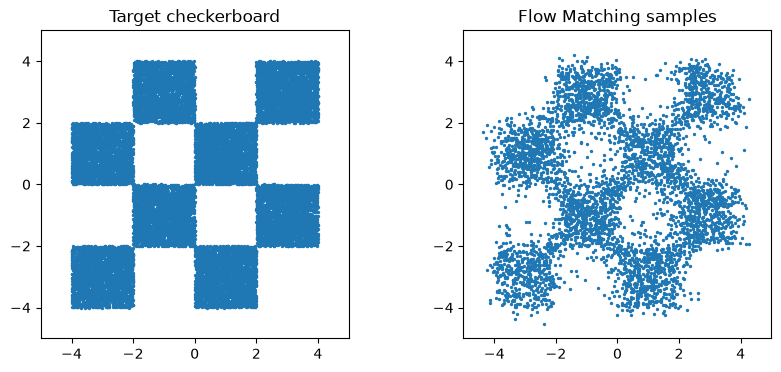

In [15]:
generated = generated.numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data[:, 0], data[:, 1], s=2)
axes[0].set_title("Target checkerboard")

axes[1].scatter(generated[:, 0], generated[:, 1], s=2)
axes[1].set_title("Flow Matching samples")

for axis in axes:
    axis.set_xlim(-5, 5)
    axis.set_ylim(-5, 5)
    axis.set_aspect("equal")

plt.show()